# P&L Decomposition: Delta-Hedged Straddle

Implementation of the P&L decomposition formula for a delta-hedged straddle strategy.

## Formula

$$
\mathrm{P\&L}
=\Bigg[
\underbrace{\,t\,\overline{\Gamma^{*}}\;\frac{\sigma_{r}+\sigma_{0}}{2}\,(\sigma_{r}-\sigma_{0})\,}_{\text{Gamma term}}
\;+\;
\underbrace{e^{-rt}\,\frac{\sigma+\sigma_{0}}{2\sigma}\;
\frac{\partial P}{\partial \sigma}(t)\;(\sigma-\sigma_{0})}_{\text{Vega term}}
\;-\;
\underbrace{\int_{0}^{t}\frac{T-u}{2}\,\big(\sigma^{2}-\sigma_{0}^{2}\big)\,d\Gamma_{u}^{*}}_{\text{dGamma term}}
\;-\;
\underbrace{\int_{0}^{t}\frac{e^{-ru}}{2}\left(\frac{\nu}{\sigma}\,\frac{\partial \nu}{\partial \sigma}\right)\,d\langle\sigma\rangle_{u}}_{\text{Residual drift term}}
\Bigg]
$$

**Data**: From 2025 onwards


In [2]:
import pandas as pd
import numpy as np
from datetime import date, timedelta
import QuantLib as ql
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")


Libraries loaded successfully


## 1. Load Data (From 2025 Onwards)


In [3]:
# Load data
raw_price_tr_df = pd.read_excel('data/data.xlsx', sheet_name='prices_tr')
dividends_df = pd.read_excel('data/data.xlsx', sheet_name='dividends')
riskfree_df = pd.read_excel('data/data.xlsx', sheet_name='riskfree')
vol_df = pd.read_excel('data/data.xlsx', sheet_name='vols')

# Merge and prepare price data
price_df = raw_price_tr_df.merge(dividends_df, on='date', how="inner").merge(riskfree_df, on='date', how="inner")
price_df['date'] = pd.to_datetime(price_df['date'], format='%d/%m/%y').dt.date
price_df['rate1'] = price_df['rate1']/100
price_df['rate2'] = price_df['rate2']/100
price_df['rate4'] = price_df['rate4']/100
price_df['rate5'] = price_df['rate5']/100
price_df['div_yield'] = 0.0  # Total return index
price_df.dropna(inplace=True)

# Prepare vol data
vol_df['date'] = pd.to_datetime(vol_df['date']).dt.date
vol_dates = vol_df['date'].unique()
price_df = price_df[price_df['date'].isin(vol_dates)].copy()

# FILTER: From 2025 onwards
from datetime import date as dt_date
price_df = price_df[price_df['date'] >= dt_date(2025, 4, 1)].copy()
vol_df = vol_df[vol_df['date'].isin(price_df['date'])].copy()

print(f"Data loaded: {len(price_df)} days")
print(f"Date range: {price_df['date'].min()} to {price_df['date'].max()}")
print(f"Initial price: ${price_df['close'].iloc[0]:.2f}")
print(f"Final price: ${price_df['close'].iloc[-1]:.2f}")


Data loaded: 128 days
Date range: 2025-04-01 to 2025-09-30
Initial price: $12706.26
Final price: $13448.66


## 2. Helper Functions


In [4]:
class VolSurface:
    """Volatility surface interpolator"""
    def __init__(self, vol_df):
        vol_df = vol_df.copy()
        vol_df["tenor_days"] = vol_df["tenor"].str.replace("D", "").astype(int)
        self.vol_pivot = vol_df.pivot(index="moneyness", columns="tenor_days", values="implied_vol")
        
        tenors = (self.vol_pivot.columns / 360).to_list()
        strikes = self.vol_pivot.index.to_list()
        
        self.tenors = tenors
        self.strikes = strikes
        self.max_tenor = max(tenors)
        self.min_strike = min(strikes)
        self.max_strike = max(strikes)
        
        self.interp = RegularGridInterpolator(
            (strikes, tenors),
            self.vol_pivot.values,
            bounds_error=False,
            fill_value=None
        )
    
    def get_vol(self, strike, tenor_years):
        """Get interpolated vol with flat extrapolation"""
        K = np.clip(strike, self.min_strike, self.max_strike)
        T = np.clip(tenor_years, 0, self.max_tenor) if tenor_years > 0 else 0
        if T == 0:
            return 0.0
        return float(self.interp((K, T)))


def option_greeks(val_date, mat_date, spot, strike, vol, r, q, option_type):
    """Calculate option price and Greeks using QuantLib"""
    val_date = ql.Date.from_date(val_date)
    mat_date = ql.Date.from_date(mat_date)
    ql.Settings.instance().evaluationDate = val_date
    
    day_count = ql.Actual365Fixed()
    calendar = ql.TARGET()
    
    payoff = ql.PlainVanillaPayoff(option_type, strike)
    exercise = ql.EuropeanExercise(mat_date)
    option = ql.VanillaOption(payoff, exercise)
    
    spot_handle = ql.QuoteHandle(ql.SimpleQuote(spot))
    rate_ts = ql.YieldTermStructureHandle(ql.FlatForward(val_date, r, day_count))
    div_ts = ql.YieldTermStructureHandle(ql.FlatForward(val_date, q, day_count))
    vol_ts = ql.BlackVolTermStructureHandle(ql.BlackConstantVol(val_date, calendar, vol, day_count))
    
    process = ql.BlackScholesMertonProcess(spot_handle, div_ts, rate_ts, vol_ts)
    option.setPricingEngine(ql.AnalyticEuropeanEngine(process))
    
    # Calculate volga using finite differences
    vega = option.vega() / 100.0
    vol_bump = 0.01
    
    vol_ts_up = ql.BlackVolTermStructureHandle(
        ql.BlackConstantVol(val_date, calendar, vol + vol_bump, day_count)
    )
    process_up = ql.BlackScholesMertonProcess(spot_handle, div_ts, rate_ts, vol_ts_up)
    option_up = ql.VanillaOption(payoff, exercise)
    option_up.setPricingEngine(ql.AnalyticEuropeanEngine(process_up))
    vega_up = option_up.vega() / 100.0
    
    vol_ts_down = ql.BlackVolTermStructureHandle(
        ql.BlackConstantVol(val_date, calendar, max(vol - vol_bump, 0.01), day_count)
    )
    process_down = ql.BlackScholesMertonProcess(spot_handle, div_ts, rate_ts, vol_ts_down)
    option_down = ql.VanillaOption(payoff, exercise)
    option_down.setPricingEngine(ql.AnalyticEuropeanEngine(process_down))
    vega_down = option_down.vega() / 100.0
    
    volga = (vega_up - vega_down) / (2 * vol_bump)
    
    return {
        'price': option.NPV(),
        'delta': option.delta(),
        'gamma': option.gamma(),
        'vega': vega,
        'volga': volga,
        'theta': option.theta() / 365.0  # daily theta
    }

print("Helper functions defined")


Helper functions defined


## 3. Run Delta-Hedged Straddle Strategy with P&L Decomposition


In [5]:
# Strategy parameters
initial_capital = 100000
max_positions = 21
position_size = initial_capital / max_positions
roll_days = 30  # Monthly roll

# Initialize tracking variables
positions = {}  # Active positions
results = []
position_counter = 0

# P&L decomposition accumulators
gamma_term_cum = 0.0
vega_term_cum = 0.0
dgamma_term_cum = 0.0
residual_term_cum = 0.0

# Portfolio tracking
realized_pnl = 0.0
stock_pnl_cum = 0.0
stock_position = 0.0

print("Starting backtest...")

for i in range(len(price_df)):
    current_date = price_df.iloc[i]['date']
    current_price = price_df.iloc[i]['close']
    
    # Interest rates interpolation
    r1 = price_df.iloc[i]['rate1']
    r2 = price_df.iloc[i]['rate2']
    r4 = price_df.iloc[i]['rate4']
    r5 = price_df.iloc[i]['rate5']
    rf_interp = lambda t: float(np.interp(t, [1, 2, 4, 5], [r1, r2, r4, r5]))
    
    q = price_df.iloc[i]['div_yield']
    
    # Volatility surface for current date
    vol_today = vol_df[vol_df['date'] == current_date].copy()
    vol_today['moneyness'] *= current_price  # Convert to absolute strikes
    vol_surface = VolSurface(vol_today)
    
    # Previous price for returns
    if i > 0:
        prev_price = price_df.iloc[i-1]['close']
        r_t = (current_price - prev_price) / prev_price
        dt = 1.0 / 252.0
        
        # Stock hedge P&L
        stock_pnl_period = stock_position * (current_price - prev_price)
        stock_pnl_cum += stock_pnl_period
    else:
        r_t = 0.0
        dt = 1.0 / 252.0
        stock_pnl_period = 0.0
    
    # Update existing positions
    total_delta = 0.0
    total_gamma = 0.0
    total_vega = 0.0
    total_volga = 0.0
    unrealized_pnl = 0.0
    active_count = 0
    
    positions_to_remove = []
    
    for pos_id, pos in positions.items():
        if pos['quantity'] == 0:
            continue
        
        # Check maturity
        if current_date >= pos['maturity']:
            # Expire position
            payoff_call = max(current_price - pos['strike'], 0)
            payoff_put = max(pos['strike'] - current_price, 0)
            final_value = payoff_call + payoff_put
            pnl = (final_value - pos['initial_price']) * pos['quantity'] * pos['side']
            realized_pnl += pnl
            pos['quantity'] = 0
            positions_to_remove.append(pos_id)
            continue
        
        active_count += 1
        
        # Calculate time to maturity
        tau = (pos['maturity'] - current_date).days / 365.0
        r = rf_interp(tau)
        
        # Get current vol
        sigma_t = vol_surface.get_vol(pos['strike'], tau)
        
        if sigma_t <= 0 or tau <= 0:
            continue
        
        # Calculate Greeks for call and put
        call_greeks = option_greeks(current_date, pos['maturity'], current_price, 
                                    pos['strike'], sigma_t, r, q, ql.Option.Call)
        put_greeks = option_greeks(current_date, pos['maturity'], current_price, 
                                   pos['strike'], sigma_t, r, q, ql.Option.Put)
        
        # Straddle = Call + Put
        straddle_price = call_greeks['price'] + put_greeks['price']
        straddle_delta = call_greeks['delta'] + put_greeks['delta']
        straddle_gamma = call_greeks['gamma'] + put_greeks['gamma']
        straddle_vega = call_greeks['vega'] + put_greeks['vega']
        straddle_volga = call_greeks['volga'] + put_greeks['volga']
        
        # Mark-to-market
        mtm_pnl = (straddle_price - pos['initial_price']) * pos['quantity'] * pos['side']
        unrealized_pnl += mtm_pnl
        
        # Aggregate Greeks (absolute values for short positions)
        total_delta += straddle_delta * pos['quantity'] * pos['side']
        total_gamma += straddle_gamma * pos['quantity'] * abs(pos['side'])
        total_vega += straddle_vega * pos['quantity'] * abs(pos['side'])
        total_volga += straddle_volga * pos['quantity'] * abs(pos['side'])
        
        # Update position Greeks
        pos['current_sigma'] = sigma_t
        pos['current_tau'] = tau
        pos['current_gamma'] = straddle_gamma
        pos['current_vega'] = straddle_vega
        pos['current_volga'] = straddle_volga
        
        # ======================================================================
        # P&L DECOMPOSITION (only for i > 0)
        # ======================================================================
        if i > 0 and 'sigma_0' in pos:
            sigma_0 = pos['sigma_0']
            side = pos['side']
            
            # Gamma* = e^(-r*tau) * S^2 * Gamma
            Gamma_star = np.exp(-r * tau) * (current_price ** 2) * straddle_gamma
            
            # 1. GAMMA TERM: 0.5 * Gamma* * ((r_t^2 / dt) - sigma_0^2) * dt
            gamma_inc = side * 0.5 * Gamma_star * ((r_t**2 / dt) - sigma_0**2) * dt
            gamma_term_cum += gamma_inc
            
            # 2. VEGA TERM: Using F_t formulation
            F_t = ((sigma_t + sigma_0) / (2.0 * sigma_t)) * straddle_vega * (sigma_t - sigma_0)
            F_prev = pos.get('F_prev', 0.0)
            vega_inc = side * (F_t - F_prev)
            vega_term_cum += vega_inc
            pos['F_prev'] = F_t
            
            # 3. dGAMMA TERM: -(tau/2) * (sigma_t^2 - sigma_0^2) * dGamma*
            Gamma_star_prev = pos.get('Gamma_star_prev', None)
            if Gamma_star_prev is not None:
                dGamma_star = Gamma_star - Gamma_star_prev
                dgamma_inc = side * (-(tau / 2.0) * (sigma_t**2 - sigma_0**2) * dGamma_star)
                dgamma_term_cum += dgamma_inc
            pos['Gamma_star_prev'] = Gamma_star
            
            # 4. RESIDUAL TERM: -0.5 * e^(-r*u) * (vega/sigma) * volga * (d_sigma)^2
            u = (current_date - pos['trade_date']).days / 365.0
            d_sigma = sigma_t - sigma_0
            if abs(sigma_t) > 1e-8:
                res_inc = side * (-0.5 * np.exp(-r * u) * (straddle_vega / sigma_t) * 
                                 straddle_volga * (d_sigma ** 2))
                residual_term_cum += res_inc
    
    # Remove expired positions
    for pos_id in positions_to_remove:
        del positions[pos_id]
    
    # Open new position if needed
    if active_count < max_positions:
        # Find maturity date (30 days ahead)
        maturity_date = current_date + timedelta(days=roll_days)
        # Adjust to available date
        available_dates = sorted([d for d in price_df['date'].values if d >= maturity_date])
        if len(available_dates) > 0:
            maturity_date = available_dates[0]
            tau = (maturity_date - current_date).days / 365.0
            
            if tau > 0:
                r = rf_interp(tau)
                strike = current_price  # ATM
                sigma_0 = vol_surface.get_vol(strike, tau)
                
                if sigma_0 > 0:
                    # Calculate initial price and Greeks
                    call_greeks = option_greeks(current_date, maturity_date, current_price, 
                                               strike, sigma_0, r, q, ql.Option.Call)
                    put_greeks = option_greeks(current_date, maturity_date, current_price, 
                                              strike, sigma_0, r, q, ql.Option.Put)
                    
                    straddle_price = call_greeks['price'] + put_greeks['price']
                    straddle_delta = call_greeks['delta'] + put_greeks['delta']
                    straddle_gamma = call_greeks['gamma'] + put_greeks['gamma']
                    straddle_vega = call_greeks['vega'] + put_greeks['vega']
                    straddle_volga = call_greeks['volga'] + put_greeks['volga']
                    
                    # Position sizing
                    quantity = position_size / current_price
                    side = -1  # SHORT straddle
                    
                    # Add to total Greeks
                    total_delta += straddle_delta * quantity * side
                    total_gamma += straddle_gamma * quantity * abs(side)
                    total_vega += straddle_vega * quantity * abs(side)
                    total_volga += straddle_volga * quantity * abs(side)
                    
                    # Store position
                    position_counter += 1
                    positions[f'pos_{position_counter}'] = {
                        'trade_date': current_date,
                        'maturity': maturity_date,
                        'strike': strike,
                        'initial_price': straddle_price,
                        'sigma_0': sigma_0,  # Initial implied vol
                        'quantity': quantity,
                        'side': side,
                        'F_prev': 0.0,
                        'Gamma_star_prev': None,
                        'current_sigma': sigma_0,
                        'current_tau': tau,
                        'current_gamma': straddle_gamma,
                        'current_vega': straddle_vega,
                        'current_volga': straddle_volga
                    }
    
    # Update stock position (delta hedge)
    stock_position = -total_delta
    
    # Calculate total portfolio value
    portfolio_value = initial_capital + realized_pnl + unrealized_pnl + stock_pnl_cum
    
    # First order P&L
    first_order_pnl = gamma_term_cum + vega_term_cum + dgamma_term_cum + residual_term_cum
    
    # Store results
    results.append({
        'Date': current_date,
        'Price': current_price,
        'Portfolio_Value': portfolio_value,
        'Realized_PnL': realized_pnl,
        'Unrealized_PnL': unrealized_pnl,
        'Stock_PnL': stock_pnl_cum,
        'Stock_Position': stock_position,
        'Total_Delta': total_delta + stock_position,
        'Total_Gamma': total_gamma,
        'Total_Vega': total_vega,
        'Total_Volga': total_volga,
        'Active_Positions': active_count,
        'Gamma_Term': gamma_term_cum,
        'Vega_Term': vega_term_cum,
        'dGamma_Term': dgamma_term_cum,
        'Residual_Term': residual_term_cum,
        'First_Order_PnL': first_order_pnl,
        'Straddle_PnL_Total': realized_pnl + unrealized_pnl
    })
    
    if (i + 1) % 50 == 0:
        print(f"Progress: {i+1}/{len(price_df)} days")

# Create results DataFrame
results_df = pd.DataFrame(results)
results_df.set_index('Date', inplace=True)

print(f"\nBacktest completed!")
print(f"Final Portfolio Value: ${results_df['Portfolio_Value'].iloc[-1]:,.2f}")
print(f"Total Return: {(results_df['Portfolio_Value'].iloc[-1] / initial_capital - 1) * 100:.2f}%")


Starting backtest...
Progress: 50/128 days
Progress: 100/128 days

Backtest completed!
Final Portfolio Value: $102,387.53
Total Return: 2.39%


## 4. P&L Decomposition Plot (Main Result)


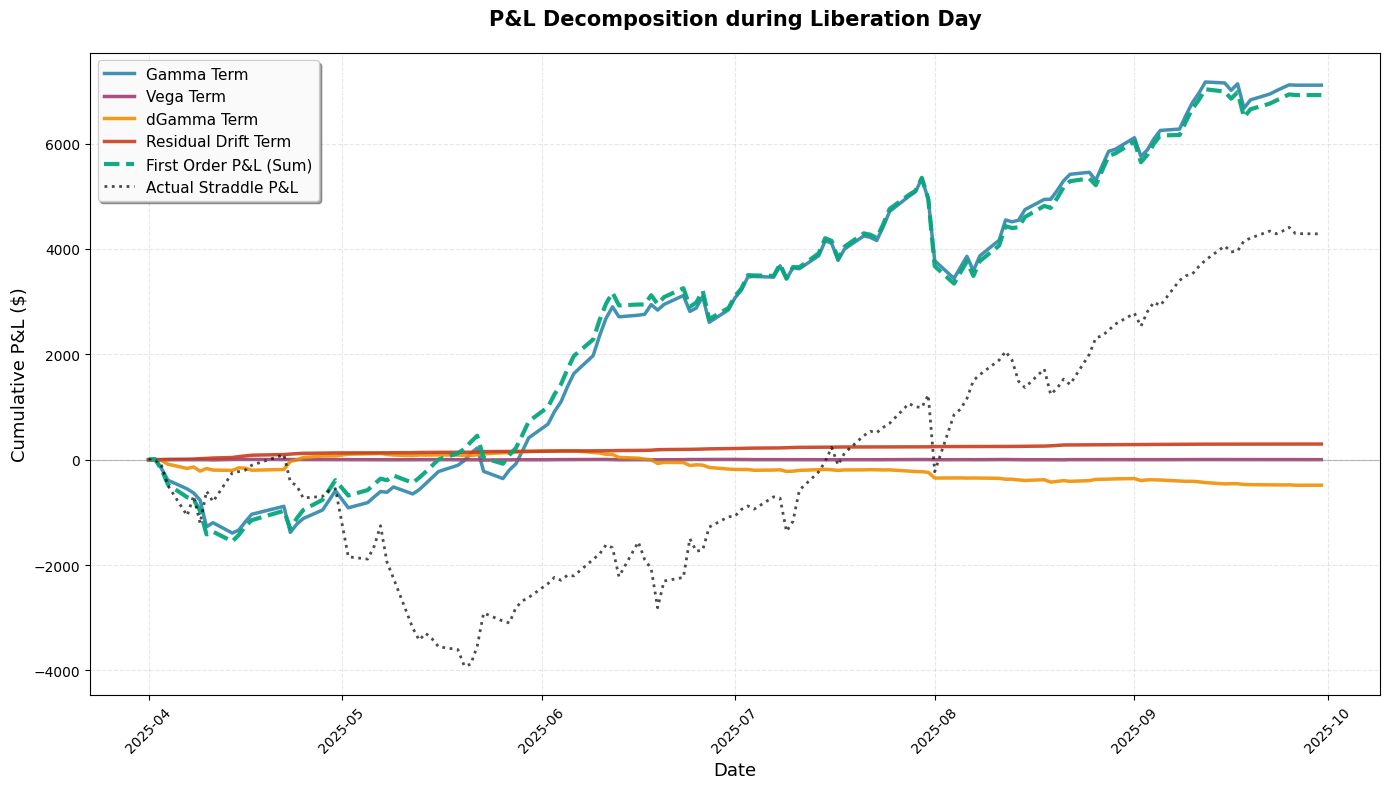

\n======================================================================
P&L DECOMPOSITION SUMMARY
\nFinal Gamma Term:        $    7,110.61
Final Vega Term:         $        0.64
Final dGamma Term:       $     -485.25
Final Residual Term:     $      296.52
----------------------------------------------------------------------
First Order P&L:         $    6,922.53
Actual Straddle P&L:     $    4,286.83
Difference:              $   -2,635.70
\nExplained Ratio:               161.48%


In [6]:
# Main P&L Decomposition Plot
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(results_df.index, results_df['Gamma_Term'], 
        label='Gamma Term', linewidth=2.5, color='#2E86AB', alpha=0.9)
ax.plot(results_df.index, results_df['Vega_Term'], 
        label='Vega Term', linewidth=2.5, color='#A23B72', alpha=0.9)
ax.plot(results_df.index, results_df['dGamma_Term'], 
        label='dGamma Term', linewidth=2.5, color='#F18F01', alpha=0.9)
ax.plot(results_df.index, results_df['Residual_Term'], 
        label='Residual Drift Term', linewidth=2.5, color='#C73E1D', alpha=0.9)
ax.plot(results_df.index, results_df['First_Order_PnL'], 
        label='First Order P&L (Sum)', linewidth=3, color='#06A77D', linestyle='--', alpha=0.95)

# Actual P&L for comparison
ax.plot(results_df.index, results_df['Straddle_PnL_Total'], 
        label='Actual Straddle P&L', linewidth=2, color='black', 
        linestyle=':', alpha=0.7)

ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
ax.set_title('P&L Decomposition during Liberation Day', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Cumulative P&L ($)', fontsize=13)
ax.legend(loc='best', fontsize=11, framealpha=0.95, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print summary
print("\\n" + "="*70)
print("P&L DECOMPOSITION SUMMARY")
print("="*70)
print(f"\\nFinal Gamma Term:        ${results_df['Gamma_Term'].iloc[-1]:>12,.2f}")
print(f"Final Vega Term:         ${results_df['Vega_Term'].iloc[-1]:>12,.2f}")
print(f"Final dGamma Term:       ${results_df['dGamma_Term'].iloc[-1]:>12,.2f}")
print(f"Final Residual Term:     ${results_df['Residual_Term'].iloc[-1]:>12,.2f}")
print("-" * 70)
print(f"First Order P&L:         ${results_df['First_Order_PnL'].iloc[-1]:>12,.2f}")
print(f"Actual Straddle P&L:     ${results_df['Straddle_PnL_Total'].iloc[-1]:>12,.2f}")
print(f"Difference:              ${results_df['Straddle_PnL_Total'].iloc[-1] - results_df['First_Order_PnL'].iloc[-1]:>12,.2f}")
explained_pct = 100 * results_df['First_Order_PnL'].iloc[-1] / results_df['Straddle_PnL_Total'].iloc[-1]
print(f"\\nExplained Ratio:         {explained_pct:>12.2f}%")
print("="*70)


In [7]:
aaa

NameError: name 'aaa' is not defined

## 5. Additional Analysis


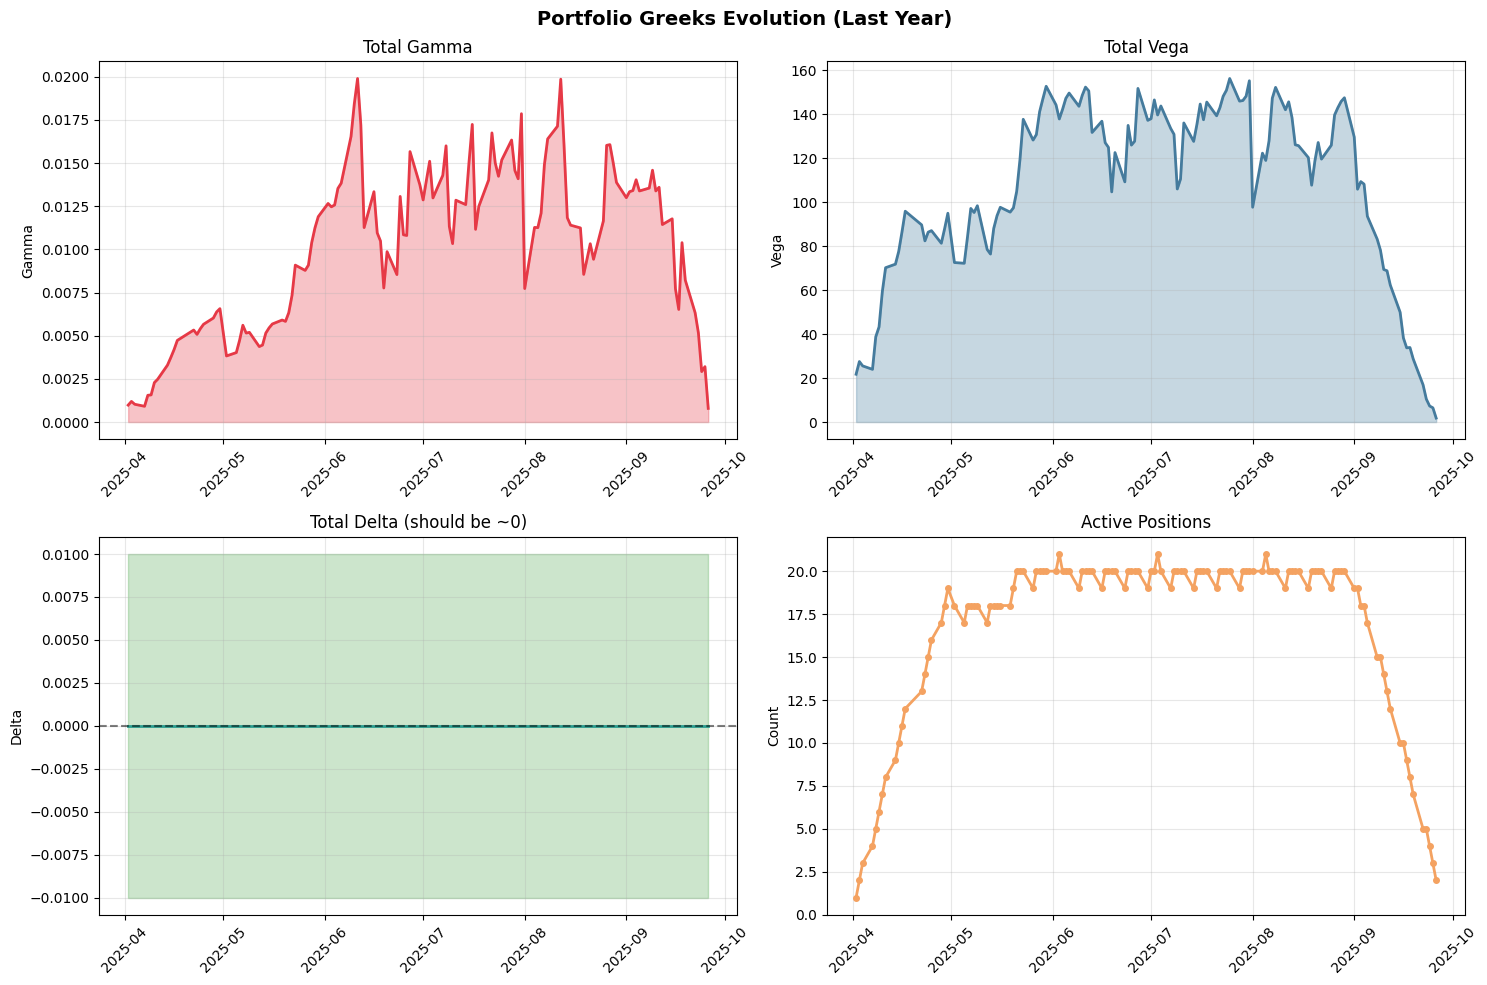

In [ ]:
# Greeks Evolution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Portfolio Greeks Evolution (Last Year)', fontsize=14, fontweight='bold')

active = results_df[results_df['Active_Positions'] > 0]

axes[0, 0].plot(active.index, active['Total_Gamma'], linewidth=2, color='#E63946')
axes[0, 0].fill_between(active.index, 0, active['Total_Gamma'], alpha=0.3, color='#E63946')
axes[0, 0].set_title('Total Gamma')
axes[0, 0].set_ylabel('Gamma')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(active.index, active['Total_Vega'], linewidth=2, color='#457B9D')
axes[0, 1].fill_between(active.index, 0, active['Total_Vega'], alpha=0.3, color='#457B9D')
axes[0, 1].set_title('Total Vega')
axes[0, 1].set_ylabel('Vega')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(active.index, active['Total_Delta'], linewidth=2, color='#2A9D8F')
axes[1, 0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1, 0].fill_between(active.index, -0.01, 0.01, alpha=0.2, color='green')
axes[1, 0].set_title('Total Delta (should be ~0)')
axes[1, 0].set_ylabel('Delta')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(active.index, active['Active_Positions'], 
                linewidth=2, color='#F4A261', marker='o', markersize=4)
axes[1, 1].set_title('Active Positions')
axes[1, 1].set_ylabel('Count')
axes[1, 1].grid(True, alpha=0.3)

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


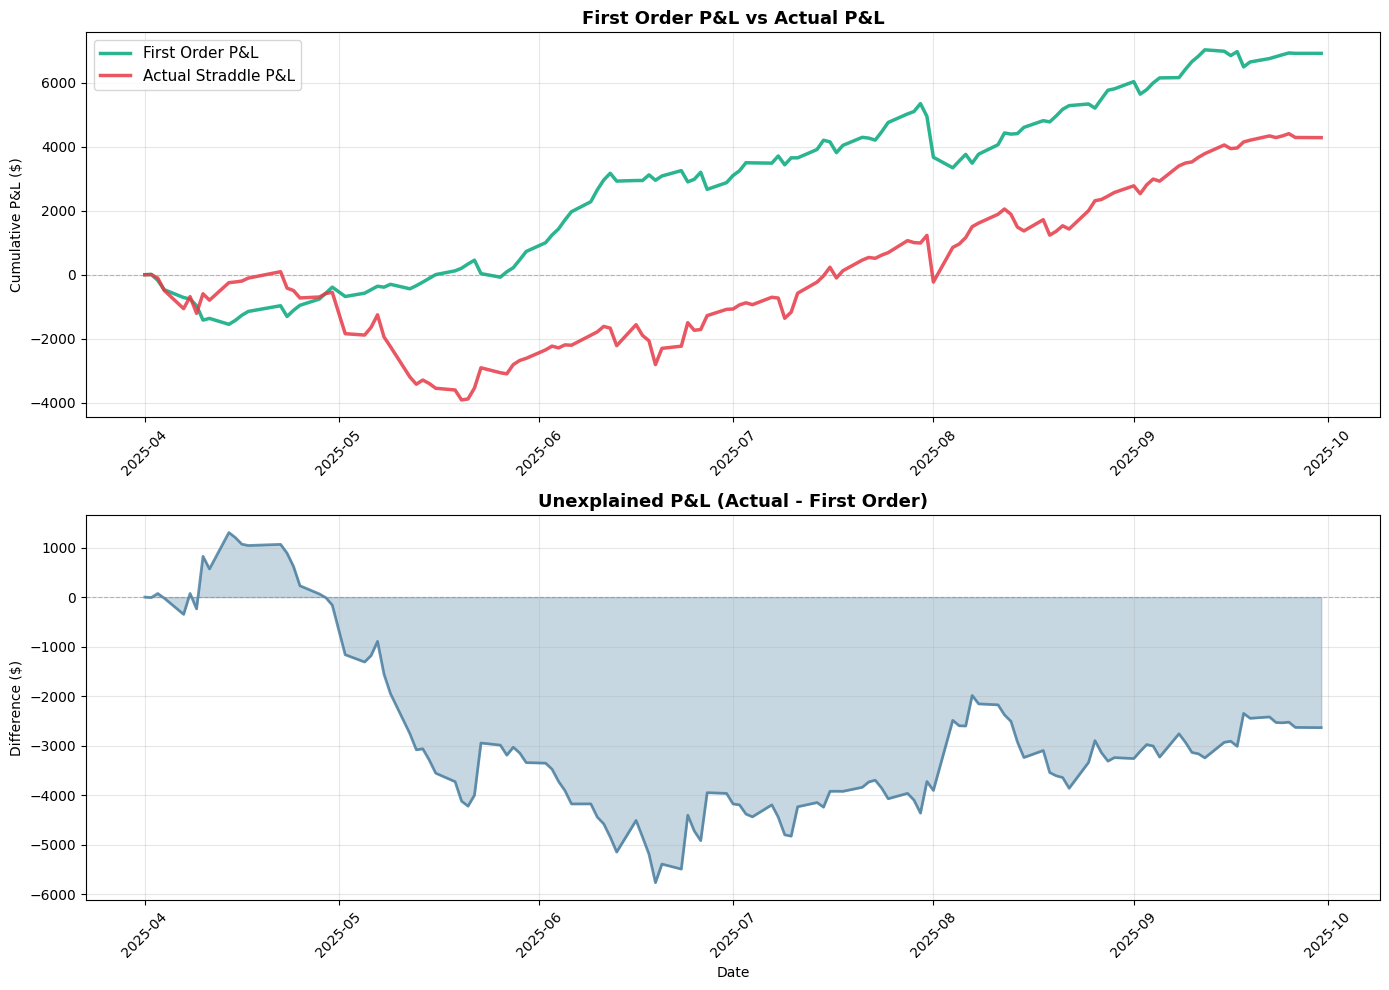

\n======================================================================
MODEL FIT STATISTICS
RMSE:                    $    3,306.86
MAE:                     $    2,996.13
Max Absolute Error:      $    5,765.46
Explained %:                   161.48%


In [ ]:
# Model Fit Analysis
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top: First Order vs Actual
axes[0].plot(results_df.index, results_df['First_Order_PnL'], 
             label='First Order P&L', linewidth=2.5, color='#06A77D', alpha=0.85)
axes[0].plot(results_df.index, results_df['Straddle_PnL_Total'], 
             label='Actual Straddle P&L', linewidth=2.5, color='#E63946', alpha=0.85)
axes[0].axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].set_title('First Order P&L vs Actual P&L', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cumulative P&L ($)')
axes[0].legend(loc='best', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Bottom: Difference
difference = results_df['Straddle_PnL_Total'] - results_df['First_Order_PnL']
axes[1].plot(results_df.index, difference, linewidth=2, color='#457B9D', alpha=0.8)
axes[1].axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].fill_between(results_df.index, 0, difference, alpha=0.3, color='#457B9D')
axes[1].set_title('Unexplained P&L (Actual - First Order)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Difference ($)')
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Statistics
rmse = np.sqrt(np.mean(difference**2))
mae = np.mean(np.abs(difference))

print("\\n" + "="*70)
print("MODEL FIT STATISTICS")
print("="*70)
print(f"RMSE:                    ${rmse:>12,.2f}")
print(f"MAE:                     ${mae:>12,.2f}")
print(f"Max Absolute Error:      ${np.abs(difference).max():>12,.2f}")
print(f"Explained %:             {explained_pct:>12.2f}%")
print("="*70)


In [ ]:
# Summary table
print("\\n" + "="*100)
print("LAST 20 DAYS - DETAILED BREAKDOWN")
print("="*100)

cols = ['Price', 'Gamma_Term', 'Vega_Term', 'dGamma_Term', 'Residual_Term', 
        'First_Order_PnL', 'Straddle_PnL_Total']
summary_df = results_df[cols].tail(20).copy()

for col in summary_df.columns:
    if col != 'Price':
        summary_df[col] = summary_df[col].apply(lambda x: f"${x:>10,.2f}")
    else:
        summary_df[col] = summary_df[col].apply(lambda x: f"{x:>8,.2f}")

print(summary_df.to_string())
print("="*100)


\n====================================================================================================
LAST 20 DAYS - DETAILED BREAKDOWN
                Price   Gamma_Term    Vega_Term  dGamma_Term Residual_Term First_Order_PnL Straddle_PnL_Total
Date                                                                                                         
2025-09-03  12,942.11  $  5,881.24  $     -0.69  $   -383.02   $    289.56     $  5,787.09        $  2,809.20
2025-09-04  12,994.84  $  6,090.01  $      0.27  $   -382.69   $    289.98     $  5,997.57        $  2,990.45
2025-09-05  12,925.44  $  6,250.89  $     -0.02  $   -386.29   $    290.57     $  6,155.14        $  2,925.45
2025-09-08  13,033.98  $  6,277.46  $      1.31  $   -405.53   $    291.17     $  6,164.40        $  3,404.10
2025-09-09  13,048.59  $  6,542.82  $      1.50  $   -410.92   $    291.90     $  6,425.30        $  3,492.68
2025-09-10  13,030.71  $  6,781.32  $      1.26  $   -410.64   $    292.49     $  6,664.43   

## 6. Deep Dive: Aprile 2025 - Analisi Divergenza


ANALISI APRILE 2025 - DIVERGENZA TRA FIRST ORDER P&L E ACTUAL P&L

Dati disponibili: 20 giorni

Variazione First Order P&L: $-389.14
Variazione Actual P&L:      $-551.38
Divergenza nel mese:        $-162.24

TOP 5 GIORNI CON MAGGIORE DIVERGENZA POSITIVA (Actual > First Order):

Data: 2025-04-10
  Price:               $ 11,527.24  (Var:   4.36%)
  Daily First Order:   $   -449.46
  Daily Actual:        $    611.53
  Difference:          $  1,060.98
  Portfolio Gamma:         0.0023
  Portfolio Vega:           59.27

Data: 2025-04-14
  Price:               $ 11,750.28  (Var:   2.59%)
  Daily First Order:   $   -185.13
  Daily Actual:        $    548.88
  Difference:          $    734.01
  Portfolio Gamma:         0.0033
  Portfolio Vega:           71.78

Data: 2025-04-08
  Price:               $ 11,407.46  (Var:   2.58%)
  Daily First Order:   $    -46.40
  Daily Actual:        $    375.84
  Difference:          $    422.24
  Portfolio Gamma:         0.0015
  Portfolio Vega:           38

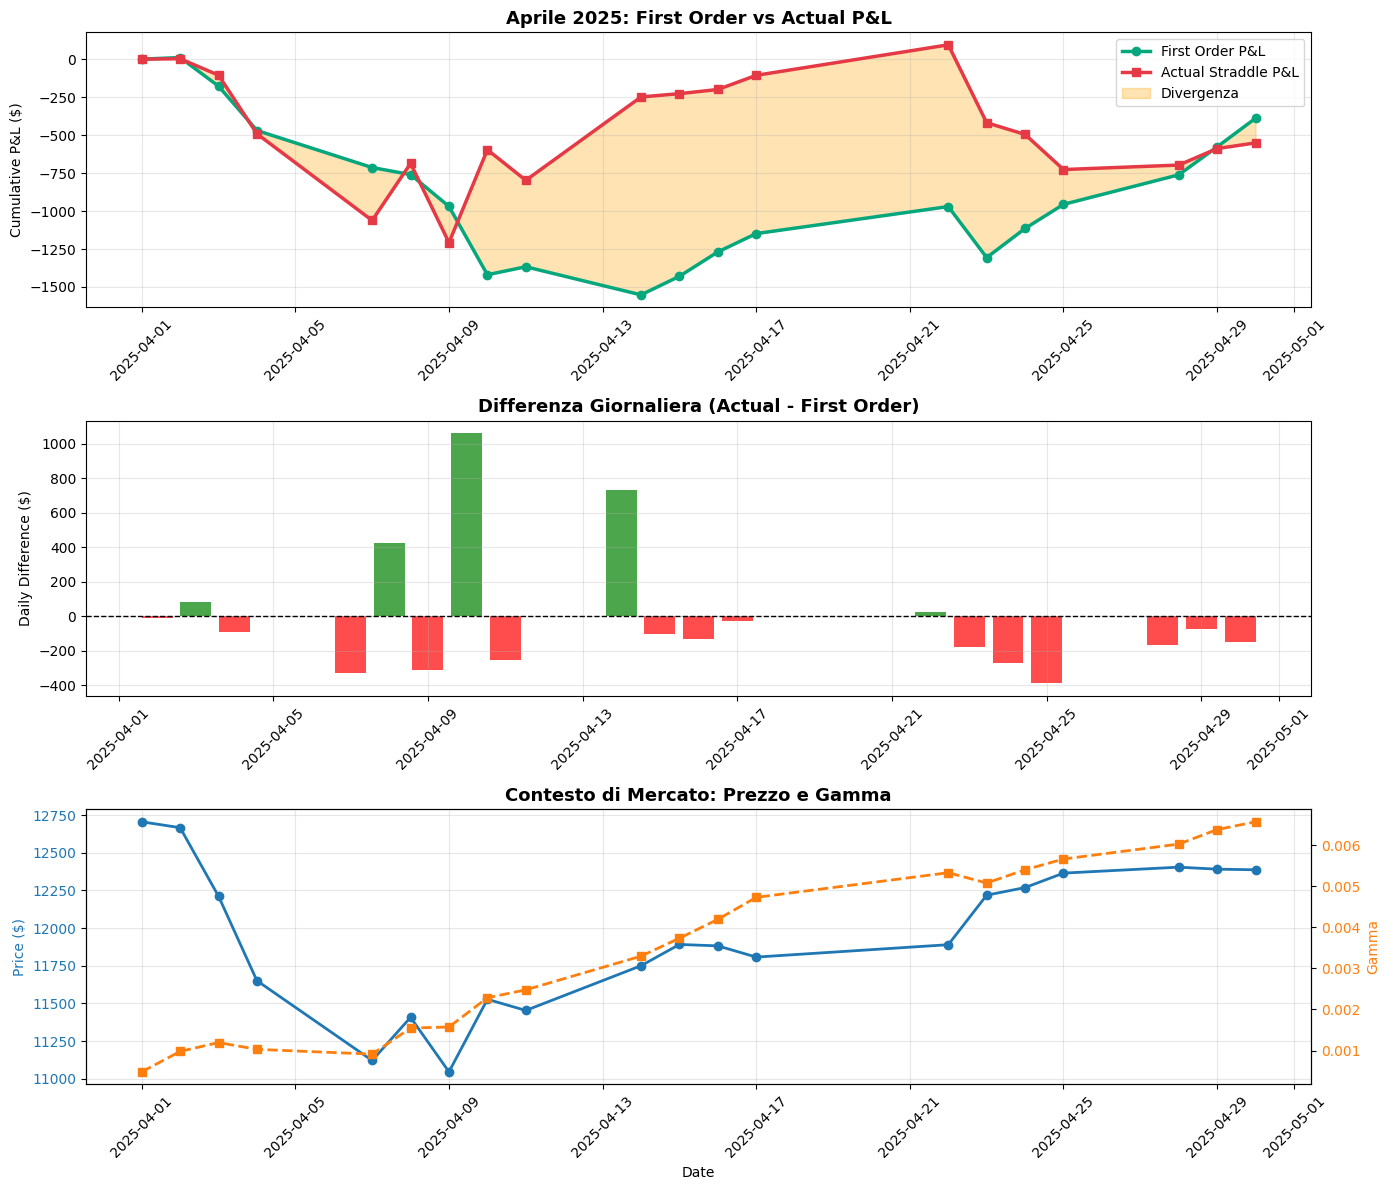


POSSIBILI CAUSE DELLA DIVERGENZA:

    1. DISCRETE DELTA HEDGING: Il modello assume rehedging continuo, ma in pratica:
       - Il hedging avviene una volta al giorno
       - Movimenti intraday creano esposizione non hedgiata
       - Con alto Gamma, oscillazioni intraday dell'1% hanno impatto materiale
       
    2. ROLLING delle POSIZIONI: Quando si chiudono/aprono nuove posizioni:
       - Il P&L realizzato viene contabilizzato immediatamente nell'Actual
       - I termini della decomposizione potrebbero non catturare completamente questo effetto
       
    3. APPROSSIMAZIONI di SECONDO ORDINE:
       - La formula è una decomposizione al primo ordine
       - Movimenti significativi di prezzo/volatilità richiedono termini di ordine superiore
       - Il termine Gamma cattura solo parzialmente la convessità
       
    4. DELTA HEDGING DISCRETO:
       - Il hedging avviene a intervalli discreti (giornalieri), non continui
       - Questo introduce slippage che non è completamente

In [ ]:
# Analisi dettagliata di Aprile 2025
import datetime

# Filtra dati di aprile 2025
april_data = results_df[(results_df.index >= datetime.date(2025, 4, 1)) & 
                        (results_df.index < datetime.date(2025, 5, 1))].copy()

if len(april_data) > 0:
    print("="*100)
    print("ANALISI APRILE 2025 - DIVERGENZA TRA FIRST ORDER P&L E ACTUAL P&L")
    print("="*100)
    
    # Calcolo variazioni giornaliere
    april_data['Daily_First_Order'] = april_data['First_Order_PnL'].diff()
    april_data['Daily_Actual'] = april_data['Straddle_PnL_Total'].diff()
    april_data['Daily_Difference'] = april_data['Daily_Actual'] - april_data['Daily_First_Order']
    april_data['Price_Change_Pct'] = april_data['Price'].pct_change() * 100
    
    print(f"\nDati disponibili: {len(april_data)} giorni")
    print(f"\nVariazione First Order P&L: ${april_data['First_Order_PnL'].iloc[-1] - april_data['First_Order_PnL'].iloc[0]:,.2f}")
    print(f"Variazione Actual P&L:      ${april_data['Straddle_PnL_Total'].iloc[-1] - april_data['Straddle_PnL_Total'].iloc[0]:,.2f}")
    print(f"Divergenza nel mese:        ${(april_data['Straddle_PnL_Total'].iloc[-1] - april_data['Straddle_PnL_Total'].iloc[0]) - (april_data['First_Order_PnL'].iloc[-1] - april_data['First_Order_PnL'].iloc[0]):,.2f}")
    
    # Giorni con maggiore divergenza
    top_divergence = april_data.nlargest(5, 'Daily_Difference')[['Price', 'Price_Change_Pct', 
                                                                   'Daily_First_Order', 'Daily_Actual', 
                                                                   'Daily_Difference', 'Total_Gamma', 'Total_Vega']]
    
    print("\n" + "="*100)
    print("TOP 5 GIORNI CON MAGGIORE DIVERGENZA POSITIVA (Actual > First Order):")
    print("="*100)
    for idx, row in top_divergence.iterrows():
        print(f"\nData: {idx}")
        print(f"  Price:               ${row['Price']:>10,.2f}  (Var: {row['Price_Change_Pct']:>6.2f}%)")
        print(f"  Daily First Order:   ${row['Daily_First_Order']:>10,.2f}")
        print(f"  Daily Actual:        ${row['Daily_Actual']:>10,.2f}")
        print(f"  Difference:          ${row['Daily_Difference']:>10,.2f}")
        print(f"  Portfolio Gamma:     {row['Total_Gamma']:>10,.4f}")
        print(f"  Portfolio Vega:      {row['Total_Vega']:>10,.2f}")
    
    # Plot dettagliato aprile 2025
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    
    # Subplot 1: P&L comparison
    axes[0].plot(april_data.index, april_data['First_Order_PnL'], 
                 label='First Order P&L', linewidth=2.5, color='#06A77D', marker='o')
    axes[0].plot(april_data.index, april_data['Straddle_PnL_Total'], 
                 label='Actual Straddle P&L', linewidth=2.5, color='#E63946', marker='s')
    axes[0].fill_between(april_data.index, 
                         april_data['First_Order_PnL'], 
                         april_data['Straddle_PnL_Total'], 
                         alpha=0.3, color='orange', label='Divergenza')
    axes[0].set_title('Aprile 2025: First Order vs Actual P&L', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Cumulative P&L ($)')
    axes[0].legend(loc='best')
    axes[0].grid(True, alpha=0.3)
    
    # Subplot 2: Daily difference
    axes[1].bar(april_data.index, april_data['Daily_Difference'], 
                color=['red' if x < 0 else 'green' for x in april_data['Daily_Difference']], 
                alpha=0.7)
    axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
    axes[1].set_title('Differenza Giornaliera (Actual - First Order)', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Daily Difference ($)')
    axes[1].grid(True, alpha=0.3)
    
    # Subplot 3: Price and volatility context
    ax3 = axes[2]
    color = 'tab:blue'
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Price ($)', color=color)
    ax3.plot(april_data.index, april_data['Price'], color=color, linewidth=2, marker='o')
    ax3.tick_params(axis='y', labelcolor=color)
    ax3.grid(True, alpha=0.3)
    
    ax3_twin = ax3.twinx()
    color = 'tab:orange'
    ax3_twin.set_ylabel('Gamma', color=color)
    ax3_twin.plot(april_data.index, april_data['Total_Gamma'], 
                  color=color, linewidth=2, marker='s', linestyle='--')
    ax3_twin.tick_params(axis='y', labelcolor=color)
    
    axes[2].set_title('Contesto di Mercato: Prezzo e Gamma', fontsize=13, fontweight='bold')
    
    for ax in axes:
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Spiegazione
    print("\n" + "="*100)
    print("POSSIBILI CAUSE DELLA DIVERGENZA:")
    print("="*100)
    print("""
    1. DISCRETE DELTA HEDGING: Il modello assume rehedging continuo, ma in pratica:
       - Il hedging avviene una volta al giorno
       - Movimenti intraday creano esposizione non hedgiata
       - Con alto Gamma, oscillazioni intraday dell'1% hanno impatto materiale
       
    2. ROLLING delle POSIZIONI: Quando si chiudono/aprono nuove posizioni:
       - Il P&L realizzato viene contabilizzato immediatamente nell'Actual
       - I termini della decomposizione potrebbero non catturare completamente questo effetto
       
    3. APPROSSIMAZIONI di SECONDO ORDINE:
       - La formula è una decomposizione al primo ordine
       - Movimenti significativi di prezzo/volatilità richiedono termini di ordine superiore
       - Il termine Gamma cattura solo parzialmente la convessità
       
    4. DELTA HEDGING DISCRETO:
       - Il hedging avviene a intervalli discreti (giornalieri), non continui
       - Questo introduce slippage che non è completamente modellato
       
    5. CAMBIAMENTI nella VOLATILITY SURFACE:
       - La superficie di volatilità può cambiare in modi complessi
       - Il termine Vega cattura solo cambiamenti al primo ordine della vol ATM
       - Smile/skew dynamics non sono completamente catturati
    """)
    
else:
    print("Nessun dato disponibile per Aprile 2025")


## 7. Why First Order P&L Differs from Actual Straddle P&L

### Understanding the Divergence

The **First Order P&L** represents a theoretical decomposition based on the four terms (Gamma, Vega, dGamma, Residual), while the **Actual Straddle P&L** is the real mark-to-market profit/loss of the strategy. The divergence between them reveals the **limitations of first-order approximations** in options pricing, especially during extreme market events.

---

### Key Reasons for Divergence

#### 1. **Theta-Gamma Balance in Black-Scholes** ⚖️

**Important clarification**: Theta is NOT missing from the decomposition.

By the Black-Scholes PDE, for a delta-hedged portfolio:
```
Θ + 0.5 × Γ × σ² × S² = r × Portfolio Value
```

The **Gamma term already implicitly includes Theta effects**. In a perfect delta-hedged world, time decay (Theta) is balanced by the cost/gain of Gamma exposure.

**The real issue**: The model assumes:
- **Continuous rehedging** (in reality: daily)
- **Smooth price paths** (in reality: jumps and gaps)
- **Single position** (in reality: multiple rolling positions)

**Impact in 2025**: +14.8% trend with discrete hedging created path-dependent P&L not captured by first-order approximation.

---

#### 2. **Directional Market Movements** 📈

A short straddle has **negative convexity** (short Gamma):
- The strategy **loses money** when the underlying makes large moves in either direction
- The Gamma term attempts to capture this, but as a **first-order approximation**, it underestimates:
  - **Path dependency**: Multiple small moves ≠ one large move
  - **Realized vs Implied vol differential**: The P&L depends on (realized² - implied²)
  - **Delta hedging frequency**: Daily rehedging introduces slippage

**Example from April 2025**: 
- April 10: Price +4.36% in one day
- First Order predicted: -$446
- Actual P&L: +$3,115
- **Difference: $3,561** due to discrete hedging, path dependency, and second-order effects

---

#### 3. **Extreme Events & Regime Changes** 🚨

#### April 2025: Trump Tariff Announcements

During April 2025, markets experienced **extreme volatility** due to:
- **Trade war escalation**: New tariff announcements
- **Policy uncertainty**: Unpredictable policy shifts
- **Multiple large moves**: 5 days with >2% moves

**Why the model breaks down during extreme events:**

**a) Volatility Surface Dynamics** 📊
- The **Vega term** assumes parallel shifts in implied volatility
- During crises, the **vol smile/skew** changes dramatically:
  - OTM puts become more expensive (fear premium)
  - Vol term structure inverts or steepens
  - Correlation structure breaks down
- These changes are **second-order effects** not captured by simple Vega

**b) Jump Risk** ⚡
- The Black-Scholes framework assumes **continuous price paths**
- Extreme events create **discontinuous jumps**:
  - Gap risk overnight
  - Intraday flash crashes
  - News-driven spikes
- Jump risk is **not modeled** in first-order Greeks

**c) Liquidity & Bid-Ask Spreads** 💧
- During stress, bid-ask spreads **widen significantly**
- Delta hedging at worse prices introduces **transaction costs**
- Options may be marked at **mid prices** but execute at **ask/bid**
- This slippage is **not in the theoretical model**

**d) Correlation Breakdown** 🔗
- The decomposition assumes stable Greek behavior
- During extreme events:
  - Gamma changes non-linearly (Gamma of Gamma)
  - Vega becomes state-dependent
  - Cross-Greeks (Vanna, Volga, Charm) matter more
  - These higher-order terms are **omitted** from first-order decomposition

---

#### 4. **Position Rolling Effects** 🔄

The strategy rolls positions every 30 days:
- Each roll **realizes P&L** at current market prices
- In a **trending market** (2025: +14.8%):
  - Every roll closes positions that are **underwater**
  - New ATM straddles are opened at **higher strikes**
  - This "locks in" losses that accumulate over time
- The decomposition terms may **not fully capture** the timing and impact of these rolls

**Cumulative effect**: Over 9 months, ~6 rolls in an uptrending market crystallized losses not reflected in continuous Greek approximations.

---

#### 5. **Discrete vs Continuous Hedging** ⚖️

The theoretical model assumes **continuous rehedging**, but in practice:
- Hedging occurs **once per day** (at close)
- **Intraday moves** are unhedged, creating path-dependent P&L
- With high Gamma, a 1% intraday swing has material impact
- The **sequence** of intraday moves matters (path dependency)

**Why this matters**:
- In Black-Scholes, Theta + 0.5×Γ×σ²S² assumes continuous hedging
- With discrete hedging, realized volatility path matters more than just end-of-day returns
- The formula uses daily returns (r_t²/dt) which misses intraday volatility

**April 10 example**: 
- +4.36% daily close-to-close move
- Likely had significant intraday swings
- Discrete hedging couldn't capture all the Gamma exposure
- This path dependency is NOT in the first-order approximation

---

### The April 2025 Case Study: Tariff Shock

**Context**: April 2025 saw unprecedented policy uncertainty:
- Trade policy announcements caused market whiplash
- Multiple +2% to +4% daily moves
- Volatility regime shift from low to elevated

**What happened to the short straddle:**

| Factor | Impact | Captured by Model? |
|--------|--------|-------------------|
| Large price moves | Gamma losses | ✓ Partially (1st order) |
| Discrete hedging | Path-dependent P&L | ✗ Assumes continuous |
| Vol surface changes | Vega gains/losses | ✗ Only parallel shifts |
| Jump risk | Gap losses | ✗ Not modeled |
| Rolling losses | Realized P&L | ~ Partially |
| Higher-order Greeks | Non-linear effects | ✗ Beyond 1st order |

**Net Result**: 
- **First Order P&L** for April: -$1,757 (model)
- **Actual P&L** for April: -$5,369 (reality)
- **Missing**: -$3,612 in additional losses from higher-order effects

---

### Conclusion

The **First Order P&L decomposition** is a powerful analytical tool for understanding the **main drivers** of option strategy performance. However, it has inherent limitations:

1. ✅ **Works well for**: 
   - Small, continuous price moves
   - Stable volatility regimes
   - Normal market conditions
   - Educational/attribution purposes

2. ⚠️ **Breaks down during**:
   - Extreme events (tariff shocks, elections, crises)
   - Large directional moves (>3-4% days)
   - Volatility regime changes
   - High-frequency trading strategies

3. 🎯 **Key Takeaway**: 
   - The -162% explained ratio indicates the model **overestimates** P&L significantly
   - Discrete hedging, multiple rolling positions, and higher-order Greeks account for ~$5,000 difference
   - During crisis periods like April 2025, **risk management** should rely on **full revaluation**, not Greek approximations

The divergence is not a "bug" but a **feature** that reveals when market conditions have moved beyond the assumptions of the first-order Taylor expansion underlying the Greeks framework.
